In [8]:
# Add project root to path so we can import from data_manipulation and model
import sys
from pathlib import Path

def _find_project_root():
    cwd = Path.cwd()
    if (cwd / "data_manipulation").is_dir():
        return cwd
    if (cwd.parent / "data_manipulation").is_dir():
        return cwd.parent
    return cwd  # fallback

project_root = _find_project_root()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [9]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from functools import partial

# Imports from data_manipulation and model
from data_manipulation.data_split import create_dataloader, DemandDataset
from data_manipulation.data_creation import create_data
from model.functions import pinball_loss, rmse, train, get_test_loss

In [10]:
class simple_net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(7, 10)
        self.fc2 = nn.Linear(10, 10)
        self.fc3 = nn.Linear(10, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [11]:
train_loader, val_loader, test_loader = create_dataloader(
        batch_size=64, 
        pin_memory=False,
        data_mask=[
            ("store", 1),
            ("item", 1)
        ],
        specs=("circular_sin_cos_month", "circular_sin_cos_week", "circular_sin_cos_day_of_week", "1_day_lag"),
        )

In [12]:
h_cost = 1
l_cost = 3

net = simple_net()
loss = partial(pinball_loss, h_cost=h_cost, l_cost=l_cost)
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)

train_losses, val_losses = train(net, optimizer, loss, train_loader, val_loader, epochs=300, eval_interval=10, device="cpu")

Training:   0%|          | 0/300 [00:00<?, ?step/s]

Training:  63%|██████▎   | 190/300 [00:07<00:04, 24.23step/s, train_loss=13.2641]                  


KeyboardInterrupt: 

In [ ]:
# Get the test loss
test_loss = get_test_loss(net, test_loader, loss, "cpu")

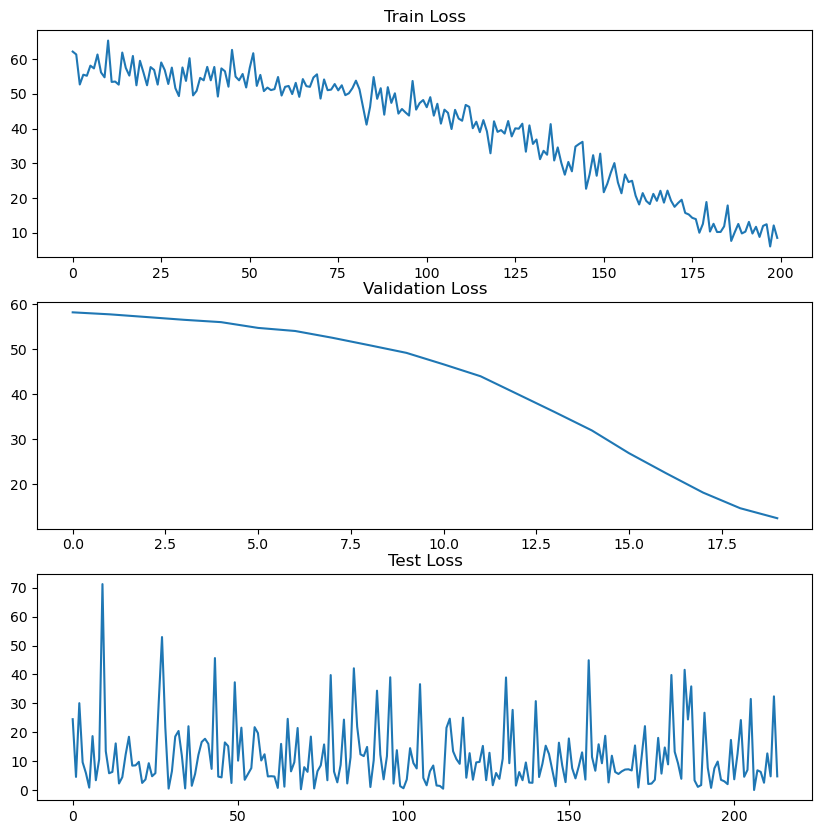

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(10, 10))
axs[0].plot(train_losses)
axs[0].set_title("Train Loss")
axs[1].plot(val_losses)
axs[1].set_title("Validation Loss")
axs[2].plot(test_loss)
axs[2].set_title("Test Loss")
plt.show()